# N-sweep / D-sweep SAGD heatmap grid

Discovers every completed run under `scripts/run/data/` matching the `run_nsweep.sh` naming scheme (`{norm}_D{d}_n{n}/D{d}_N{n}_T{T}`) and plots a grid of SAGD distance-matrix heatmaps: **columns = dimension `d`**, **rows = `n_samples`**. Cells for a (d, n) combination that hasn't been run yet (or is still in progress) are left blank.

Currently `run_nsweep.sh` only sweeps `n_samples` at a fixed `D=1024`, so the grid will show a single populated column until more dimensions are run under the same naming scheme -- no notebook changes needed when that happens, just re-run it.

In [17]:
import re
from pathlib import Path

import numpy as np
import joblib
import matplotlib.pyplot as plt

from lib.ou_model import find_third_phase_onset
from lib.viz.plotting import _draw_sagd_heatmap_with_prob


## Discover runs

Parses `NORM` and `T` out of `run_nsweep.sh` (assumed fixed across the sweep), then finds every `{NORM}_D{d}_n{n}` experiment directory on disk and checks whether its pipeline outputs are complete.

In [18]:
NSWEEP_SCRIPT = Path("../scripts/run/run_nsweep.sh")
NSWEEP_DATA_ROOT = Path("../scripts/run/data")


def parse_bash_vars(script_path: Path) -> dict:
    """Pull simple `VAR=value` / `VAR="value"` assignments out of the sweep script."""
    text = script_path.read_text()
    values = dict(re.findall(r'^(\w+)=([0-9.]+)\s*$', text, flags=re.MULTILINE))
    values.update(re.findall(r'^(\w+)="([^"]*)"\s*$', text, flags=re.MULTILINE))
    return values


cfg = parse_bash_vars(NSWEEP_SCRIPT)
NORM = cfg["NORM"]
T = float(cfg["T"])

REQUIRED_FILES = ["history.jbl", "Ws.jbl", "CTDs.jbl", "SAGD.jbl", "clusters.jbl"]
EXP_PATTERN = re.compile(rf"^{re.escape(NORM)}_D(\d+)_n(\d+)$")

run_dirs = {}  # (d, n_samples) -> run_dir
for exp_dir in sorted(p for p in NSWEEP_DATA_ROOT.iterdir() if p.is_dir()):
    m = EXP_PATTERN.match(exp_dir.name)
    if not m:
        continue
    d, n = int(m.group(1)), int(m.group(2))
    run_dir = exp_dir / f"D{d}_N{n}_T{int(T)}"
    missing = [f for f in REQUIRED_FILES if not (run_dir / f).exists()]
    if missing:
        print(f"Skipping D={d}, n_samples={n}: run not finished yet (missing {missing}) at {run_dir}")
        continue
    run_dirs[(d, n)] = run_dir

d_list = sorted({d for d, _ in run_dirs})
n_list = sorted({n for _, n in run_dirs})
print(f"Discovered grid: dimensions={d_list}, n_samples={n_list}")


Discovered grid: dimensions=[1024], n_samples=[1000, 2000, 4000]


## Load data

One entry per completed `(d, n_samples)` combination; missing combinations simply aren't keys in `grid_data` and are left blank in the plot.

In [21]:
grid_data = {}
std = 1.0  # bimodal_gaussian std used throughout the sweep

for (d, n), run_dir in run_dirs.items():
    history = joblib.load(run_dir / "history.jbl")
    breakpoints = joblib.load(run_dir / "clusters.jbl")
    ctds = joblib.load(run_dir / "CTDs.jbl")
    snaps = np.asarray(history["params"]["times_snapshots"])

    grid_data[(d, n)] = dict(
        W=joblib.load(run_dir / "SAGD.jbl"),
        time_snaps=snaps,
        ts=history["params"].get("ts_theoretical"),
        tsagd=snaps[breakpoints[0]],
        tstar=find_third_phase_onset(ctds["CTDs"], snaps),
        ctds=ctds,
        mu=history["params"]["mu"],
    )
    del history

print(f"Loaded {len(grid_data)} / {len(run_dirs)} (d, n_samples) combinations")


Loaded 3 / 3 (d, n_samples) combinations


## Grid plot

Reuses `lib.viz.plotting._draw_sagd_heatmap_with_prob` per cell instead of redrawing the heatmap here. That helper ties its title and the theoretical same-cluster probability curve `φ(t)` to the same `d` argument -- which is exactly right in this grid, since `d` genuinely varies by column (unlike the earlier n_samples-only row plot, where `d` was fixed and had to be decoupled from the label).

In [22]:
def plot_sagd_heatmap_grid(
        grid_data, d_list, n_list, std,
        distance='SAGD', show_prob=True, show_legend=True,
        clipping=True, save_fig_path=None,
):
    """
    Grid of SAGD-distance heatmaps: columns = dimension `d`, rows = `n_samples`.
    `grid_data` maps (d, n_samples) -> dict with keys W, time_snaps, ts,
    tsagd, tstar, ctds, mu. Missing (d, n_samples) combinations are left blank.
    """
    if not d_list or not n_list:
        raise ValueError("d_list / n_list is empty -- no completed runs to plot.")

    nrows, ncols = len(n_list), len(d_list)
    fig, axes = plt.subplots(
        nrows=nrows, ncols=ncols,
        figsize=(6 * ncols, 9.5 * nrows),
        gridspec_kw={'wspace': 0.5, 'hspace': 0.6},
        squeeze=False,
    )

    for row, n in enumerate(n_list):
        for col, d in enumerate(d_list):
            ax = axes[row, col]
            cell = grid_data.get((d, n))
            if cell is None:
                ax.axis('off')
                ax.text(0.5, 0.5, f"D={d}, N={n}\n(no data)",
                        ha='center', va='center', fontsize=11, color='gray',
                        transform=ax.transAxes)
                continue

            _draw_sagd_heatmap_with_prob(
                ax_hm=ax,
                W=cell["W"],
                time_vector=cell["time_snaps"],
                d=d,
                mu=cell["mu"],
                std=std,
                ts=cell["ts"],
                tsagd=cell["tsagd"],
                t_star=cell["tstar"],
                show_ylabel=(col == 0),
                show_legend=show_legend,
                show_prob=show_prob,
                distance=distance,
                ctds=cell["ctds"],
                model='synthetic',
                clipping=clipping,
            )
            if col == 0:
                ax.set_ylabel(f"N={n}\nTime", fontsize=12)

    if save_fig_path:
        Path(save_fig_path).parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_fig_path, dpi=300, bbox_inches='tight')
    plt.show()


## Plot

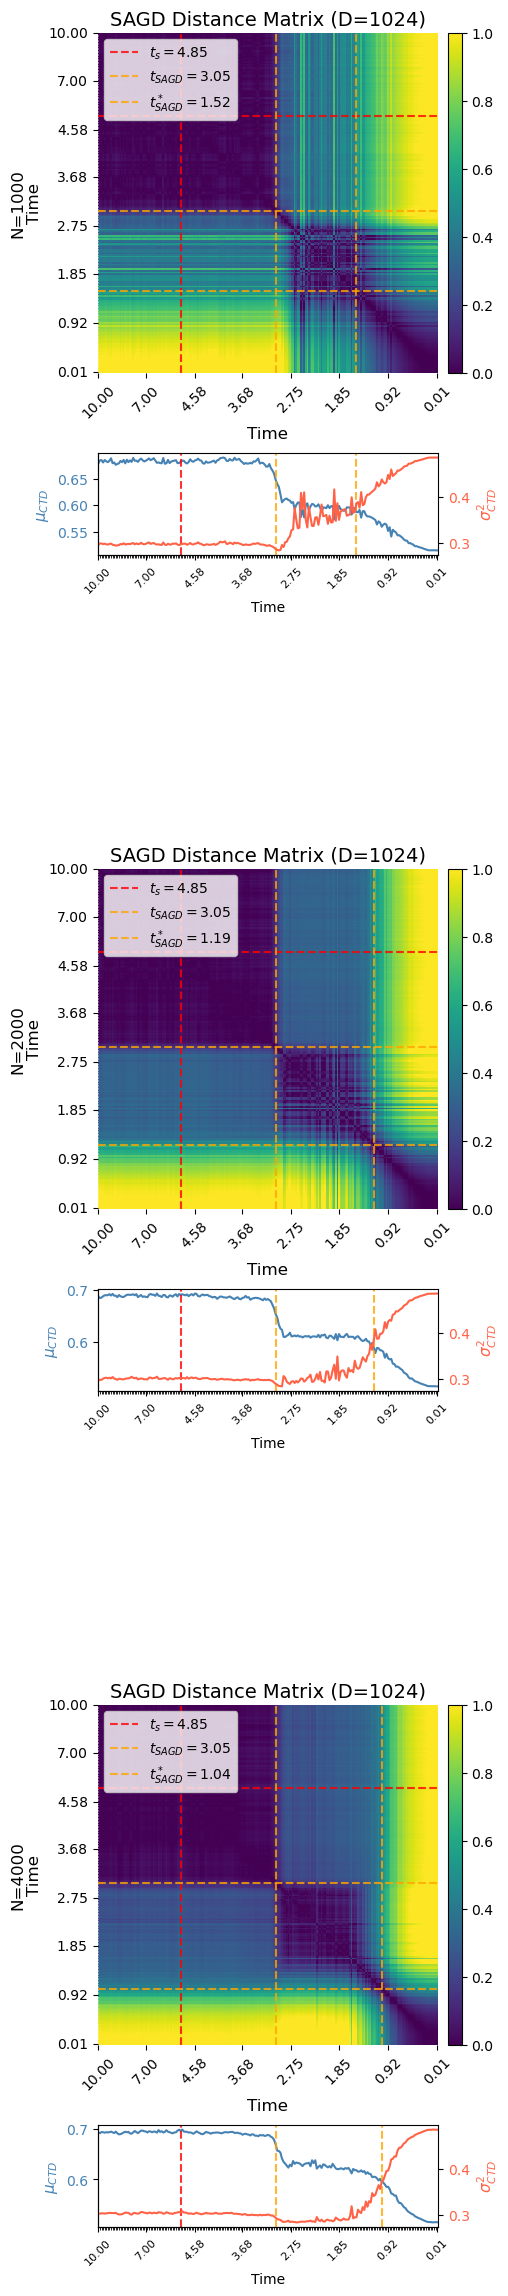

In [23]:
plot_sagd_heatmap_grid(
    grid_data=grid_data,
    d_list=d_list,
    n_list=n_list,
    std=std,
    distance='SAGD',
    show_prob=False,
    save_fig_path='figs/sagd_heatmap_grid_d_x_nsamples.png',
)
